# Holiday Destination Index — Combined Analysis
---

This notebook combines three cleaned datasets into a single master CSV and then performs a full multivariate analysis to build a composite *'Best Country to Visit'* index.

**Datasets used:**

| Dataset | Source File | Pillar |
|---|---|---|
| Cost of Living | `Cleaned_CostOfLiving.csv` | Economy |
| Global Weather | `Cleaned_GlobalWeather.csv` | Environment |
| Natural Disasters | `Cleaned_NaturalDisasters.csv` | Risk |

---

## Part 1 — Data Loading & Combination

Load the three cleaned CSV files, verify each for NaN values, merge them on `country`, and export the final combined dataset.

### 1.1 — Load Datasets


In [26]:
import pandas as pd

# Load the three cleaned datasets 
cost_of_living = pd.read_csv('Cleaned_Csvs/Cleaned_CostOfLiving.csv')
weather        = pd.read_csv('Cleaned_Csvs/Cleaned_GlobalWeather.csv')
disasters      = pd.read_csv('Cleaned_Csvs/Cleaned_NaturalDisasters.csv')

print(f"Cost of Living rows : {len(cost_of_living)}")
print(f"Weather rows        : {len(weather)}")
print(f"Disasters rows      : {len(disasters)}")

for name, df in [("Cost of Living", cost_of_living), ("Weather", weather), ("Disasters", disasters)]:
    nan_counts = df.isnull().sum()
    nan_counts = nan_counts[nan_counts > 0]
    print(f"\n--- {name} NaN counts ---")
    if nan_counts.empty:
        print("  No NaN values")
    else:
        print(nan_counts.to_string())


Cost of Living rows : 203
Weather rows        : 201
Disasters rows      : 156

--- Cost of Living NaN counts ---
  No NaN values

--- Weather NaN counts ---
  No NaN values

--- Disasters NaN counts ---
  No NaN values


### 1.2 — Merge Datasets

Merge the three datasets on `country`:
- **Inner join** `CostOfLiving` + `Weather` — only countries present in both are kept.
- **Left join** `Disasters` onto the result — countries with no disaster record are filled with `0`, assuming no recorded events.


In [27]:
# Step 1: inner join cost_of_living + weather (both MUST be present)
combined = pd.merge(
    cost_of_living, 
    weather, 
    on='country', 
    how='inner'
)
print(f"After inner join (cost_of_living + weather): {len(combined)} rows")

# Step 2: left join disasters onto combined
disaster_numeric_cols = disasters.select_dtypes(include='number').columns.tolist()

combined = pd.merge(
    combined,
    disasters,
    on='country',
    how='left'
)

# Fill missing disaster numeric values with 0
# For countries in 'combined' that don't appear in the disaster dataset I assume they had 0 disasters
# so I fill NaNs with 0
combined[disaster_numeric_cols] = combined[disaster_numeric_cols].fillna(0)

# Sort by country and reset index
combined = combined.sort_values('country').reset_index(drop=True)

print(f"Combined rows : {len(combined)}")
print(f"Combined cols : {combined.shape[1]}")
combined.head(10)

After inner join (cost_of_living + weather): 170 rows
Combined rows : 170
Combined cols : 14


,country,Mid_range_meal_pp,One_way_local_transport_ticket,Apartment,temperature_celsius,wind_kph,humidity,uv_index,condition_text,condition_category,HRS_of_light,Disaster_Count,Median_Severity,Unique_Days_Under_Threat
0,Afghanistan,3.41,0.22,79.900,18.754247,10.340000,28.046575,4.694795,sunny,Clear,0.60,6.0,0.50,22.0
1,Albania,12.48,0.43,186.790,21.625479,9.776438,50.805479,4.181096,sunny,Clear,0.46,1.0,0.00,7.0
2,Algeria,6.66,0.21,143.880,22.275068,14.090685,58.019178,3.846849,partly cloudy,Partly Cloudy,0.50,5.0,0.25,8.0
3,Andorra,20.17,1.90,811.730,10.402192,9.050137,61.750685,2.798630,sunny,Clear,0.46,0.0,0.00,0.0
4,Angola,32.12,0.59,220.390,27.371233,11.057808,70.923288,6.942192,partly cloudy,Partly Cloudy,0.49,2.0,1.00,11.0
5,Antigua And Barbuda,46.26,1.02,393.905,26.745479,22.950959,78.219178,2.157260,partly cloudy,Partly Cloudy,0.45,0.0,0.00,0.0
6,Argentina,13.76,0.35,205.320,15.151781,10.493973,82.221918,1.733699,sunny,Clear,0.41,4.0,0.50,62.0
7,Armenia,15.84,0.25,540.260,18.325205,7.910411,38.172603,4.780548,partly cloudy,Partly Cloudy,0.51,2.0,0.50,6.0
8,Australia,31.15,2.75,1142.780,12.974247,10.600274,74.123288,0.417534,clear,Clear,0.61,8.0,0.25,27.0
9,Austria,28.49,2.41,707.550,14.389589,14.013973,62.309589,3.298630,partly cloudy,Partly Cloudy,0.55,2.0,0.00,9.0


### 1.3 — Export Combined Dataset

Save the merged 170-row dataset to `Combined_Holiday.csv` for use in all subsequent analysis.


In [28]:
combined.to_csv('Combined_Holiday.csv', index=False)
print("Saved to Combined_Holiday.csv")
combined.info()

Saved to Combined_Holiday.csv
<class 'pandas.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   country                         170 non-null    str    
 1   Mid_range_meal_pp               170 non-null    float64
 2   One_way_local_transport_ticket  170 non-null    float64
 3   Apartment                       170 non-null    float64
 4   temperature_celsius             170 non-null    float64
 5   wind_kph                        170 non-null    float64
 6   humidity                        170 non-null    float64
 7   uv_index                        170 non-null    float64
 8   condition_text                  170 non-null    str    
 9   condition_category              170 non-null    str    
 10  HRS_of_light                    170 non-null    float64
 11  Disaster_Count                  170 non-null    float64
 12  Median_Severity  

# Part 2 — Multivariate Analysis: PCA for a Global Stability & Cost Index
---
Principal Component Analysis (PCA) is used to uncover the underlying structure of the dataset across all **three datasets**:

| Dataset | Indicators |
|---|---|
| **Economy** | `Mid_range_meal_pp`, `One_way_local_transport_ticket`, `Apartment` |
| **Environment** | `temperature_celsius`, `wind_kph`, `humidity`, `uv_index`, `HRS_of_light` |
| **Risk** | `Disaster_Count`, `Median_Severity`, `Unique_Days_Under_Threat` |

PCA reduces these 11 dimensions to orthogonal components, revealing which indicators drive variance across countries and how countries cluster in reduced space.


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from pandas.plotting import parallel_coordinates

df = pd.read_csv('Combined_Holiday.csv')

NUMERIC_COLS = [
    'Mid_range_meal_pp', 'One_way_local_transport_ticket', 'Apartment',
    'temperature_celsius', 'wind_kph', 'humidity', 'uv_index', 'HRS_of_light',
    'Disaster_Count', 'Median_Severity', 'Unique_Days_Under_Threat'
]


## 2.1 — Correlation Heatmap
Shows the pairwise correlation between all numeric features. Strong positive/negative correlations indicate variables that have high correlation.

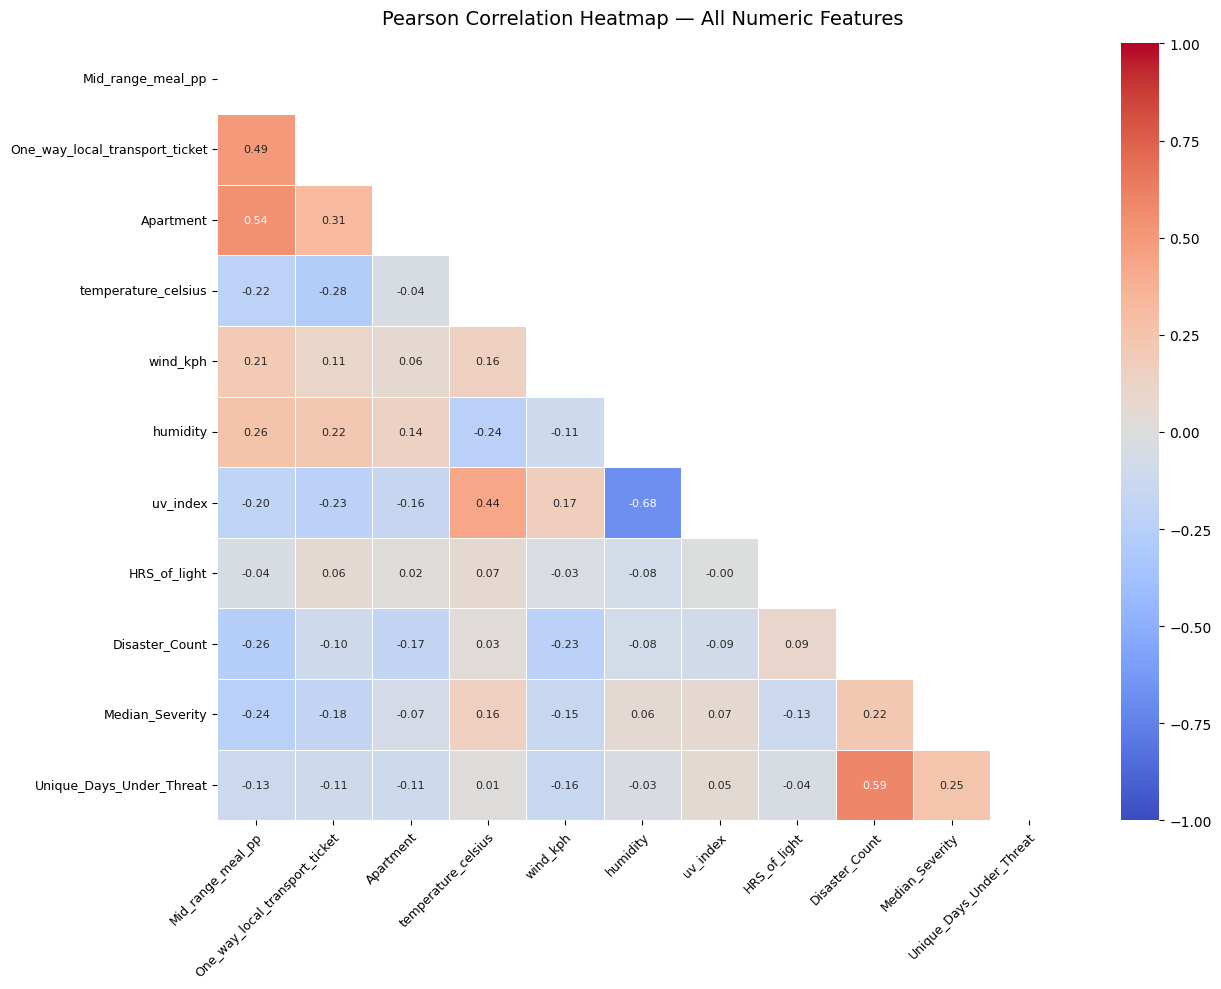

In [30]:
corr = df[NUMERIC_COLS].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))   # upper triangle masked
sns.heatmap(
    corr,
    mask=mask,
    annot=True, fmt=".2f",
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    annot_kws={"size": 8},
    ax=ax
)
ax.set_title('Pearson Correlation Heatmap — All Numeric Features', fontsize=14, pad=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor', fontsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)
plt.tight_layout()
plt.show()


### Findings

To interpret the heatmap, I used the following standard thresholds:

| Range (absolute value) | Strength |
|---|---|
| 0.8 – 1.0 | Perfect / Very Strong |
| 0.6 – 0.8 | Strong |
| 0.4 – 0.6 | Moderate |
| 0.2 – 0.4 | Weak |
| 0.0 – 0.2 | Negligible / No correlation |

By analysing the relationships between my variables using the heatmap, I found that **most correlations fall in the weak-to-no-correlation range**, with the exception of a few notable outliers outlined below.

---

**Humidity vs. UV Index (`-0.68`) — Strong Negative**
High humidity typically means more cloud cover, which blocks UV light. This makes intuitive sense: if you want a dry, sunny holiday destination, you'll likely encounter higher UV levels.

**Disaster Count vs. Days Under Threat (`+0.59`) — Moderate–Strong Positive**
These two metrics move together logically — the more individual disaster events a country experiences, the more days it will naturally be flagged as under threat.

**Temperature vs. UV Index (`+0.44`) — Moderate Positive**
As expected, hotter countries tend to experience more intense direct sunlight, resulting in higher UV readings.

**The "Cost Cluster" — Moderate Positive**
`Mid_range_meal_pp` correlates with both `Apartment` (`0.54`) and `One_way_local_transport_ticket` (`0.49`). This confirms that prices across different sectors tend to rise and fall together within a country, reinforcing the validity of grouping them into a single **Economic Pillar** for the index.

In [31]:
from scipy.stats import pearsonr
pair = df[['uv_index', 'humidity']]
corr = pearsonr(pair['uv_index'], pair['humidity'])
print(corr)

PearsonRResult(statistic=np.float64(-0.6820812207396673), pvalue=np.float64(1.3110466347784513e-24))


-0.68: This shows a strong negative link. When humidity is high, the UV index is usually low (likely due to cloud cover). When the sky is clear and dry, the UV index is high.

The P-value 1.3110466347784513e-24: This is a tiny number, much smaller than 0.05. It means the result is statistically significant. There is essentially a 0% chance this relationship happened by luck.

A correlation of -0.68 means they share some info, but they aren't identical. If I delete one, I will lose the 32% of unique data that the other variable has. Keeping both of these will help PCA define the Environmental Pillar more clearly. PCA's job is to take correlated variables and "squash" them into a single component. It expects collinearity.

## 2.3 — Scree Plot 

The scree plot shows how many components are needed to capture the majority of the dataset's variance. The **elbow** (where the individual bars flatten) marks the natural cut-off. The orange line shows cumulative variance.


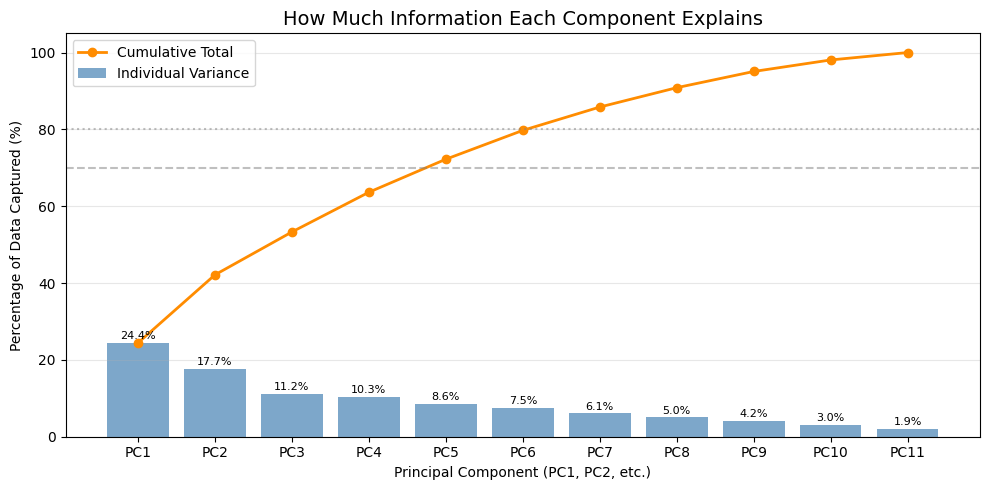

In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Standardise (scales differ: €, °C, disaster counts)
X_std = StandardScaler().fit_transform(df[NUMERIC_COLS].fillna(0).values)

# Fit PCA on all components
pca      = PCA(random_state=42)
pca.fit(X_std)
n_comp   = len(NUMERIC_COLS)
ev_ratio = pca.explained_variance_ratio_ * 100
ev_cum   = np.cumsum(ev_ratio)

# Loadings table
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(n_comp)],
    index=NUMERIC_COLS
)


# ── Scree plot ────────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
components = np.arange(1, n_comp + 1)

plt.bar(components, ev_ratio, color='steelblue', alpha=0.7, label='Individual Variance')
plt.plot(components, ev_cum, color='darkorange', marker='o', linewidth=2, label='Cumulative Total')

plt.axhline(y=70, color='gray', linestyle='--', alpha=0.5)
plt.axhline(y=80, color='gray', linestyle=':', alpha=0.5)

for i, percentage in enumerate(ev_ratio):
    plt.text(i + 1, percentage + 1, f'{percentage:.1f}%', ha='center', fontsize=8)

plt.title('How Much Information Each Component Explains', fontsize=14)
plt.xlabel('Principal Component (PC1, PC2, etc.)')
plt.ylabel('Percentage of Data Captured (%)')
plt.xticks(components, [f'PC{i}' for i in components])
plt.legend(loc='best')
plt.ylim(0, 105)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
pc1 = loadings['PC1'].sort_values()
print("\nPC1 Loadings (sorted strongest → weakest):")
print(loadings['PC1'].sort_values(ascending=False).round(3).to_string())



PC1 Loadings (sorted strongest → weakest):
Mid_range_meal_pp                 0.463
One_way_local_transport_ticket    0.401
Apartment                         0.348
uv_index                          0.347
humidity                          0.339
temperature_celsius               0.292
Disaster_Count                    0.259
Unique_Days_Under_Threat          0.235
Median_Severity                   0.229
wind_kph                          0.088
HRS_of_light                      0.014


### Scree Plot Interpretation

To develop a meaningful composite indicator, I performed **Principal Component Analysis (PCA)** on the 11 numeric variables in the dataset. This allowed me to study the underlying structure of the data and ensure that the final index represents a truly multidimensional concept, rather than being driven by a single factor.

The scree plot shows a clear **elbow at PC6**. Up to this point, each component contributes meaningful information; after PC6, additional components add relatively small gains.

- **Variance Captured:** Retaining **6 Principal Components** captures **79.7%** of total variance which is a strong coverage level for index construction.
- **Solves Double Counting:** The original dataset contains multiple indicators for the same broad concepts (for example, three cost). PCA groups shared variance into common components, so one pillar does not dominate simply because it has more columns.
- **Handles Multicollinearity:** Correlated inputs (such as humidity and UV index) are transformed into **orthogonal (uncorrelated) components**, which reduces redundancy and gives a cleaner basis for combining Economy, Environment, and Risk dimensions into one index.
- **Dimensionality:** Keeping these six components ensures the final *'Best Country to Visit'* index remains multidimensional, instead of collapsing into a single-factor score.